<a href="https://colab.research.google.com/github/camilodel02/Supervised-Learning/blob/main/TelephoneChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Lectura Datos

In [ ]:
data_train=pd.read_excel('/content/traintelco.xlsx')
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8243 entries, 0 to 8242
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     8243 non-null   int64         
 1   Fecha de nacimiento    8243 non-null   datetime64[ns]
 2   tipo cliente           8243 non-null   int64         
 3   Factura online         8243 non-null   int64         
 4   Antigüedad Equipo      8243 non-null   int64         
 5   Plan de datos          8243 non-null   int64         
 6   facturación            8243 non-null   int64         
 7   mora                   8243 non-null   int64         
 8   Fecha inicio contrato  8243 non-null   datetime64[ns]
 9   minutos                8243 non-null   int64         
 10  resultado              8243 non-null   int64         
dtypes: datetime64[ns](2), int64(9)
memory usage: 708.5 KB


In [ ]:
data_train.head()

,id,Fecha de nacimiento,tipo cliente,Factura online,Antigüedad Equipo,Plan de datos,facturación,mora,Fecha inicio contrato,minutos,resultado
0,5,1990-05-01 00:05:22.046,2,1,9,0,44588,34,2017-12-22 10:09:47.504,644,0
1,8,1980-06-30 19:08:57.680,2,0,41,1,341480,3,2017-07-28 02:54:52.022,663,0
2,9,1984-10-10 21:23:28.869,2,0,38,1,230662,20,2017-06-29 08:15:47.525,1039,1
3,11,1986-07-01 08:58:42.308,2,1,11,1,205336,9,2017-03-13 18:39:25.308,535,0
4,16,1986-01-23 00:26:52.782,1,1,6,0,429525,0,2015-08-02 21:50:40.258,1869,0


##EDA

In [ ]:
data_train.describe()

,id,Fecha de nacimiento,tipo cliente,Factura online,Antigüedad Equipo,Plan de datos,facturación,mora,Fecha inicio contrato,minutos,resultado
count,8243.000000,8243,8243.000000,8243.000000,8243.000000,8243.000000,8243.000000,8243.000000,8243,8243.000000,8243.000000
mean,9172.917142,1958-04-08 05:07:49.822340416,1.655223,0.489142,24.271018,0.841077,267765.690404,18.130171,2017-01-01 23:38:29.680386048,1183.822759,0.165110
min,5.000000,1940-09-10 08:22:07.655000,1.000000,0.000000,1.000000,0.000000,-112588.000000,0.000000,2011-12-13 07:49:29.133000,100.000000,0.000000
25%,4616.500000,1955-01-16 17:56:56.843500032,1.000000,0.000000,9.000000,1.000000,203363.000000,0.000000,2016-06-14 08:32:32.550500096,708.000000,0.000000
50%,9143.000000,1958-03-25 11:21:40.669000,2.000000,0.000000,24.000000,1.000000,268063.000000,6.000000,2017-03-04 16:27:59.860000,1103.000000,0.000000
75%,13759.500000,1961-05-01 21:38:50.065000,2.000000,1.000000,39.000000,1.000000,333272.500000,35.000000,2017-09-18 21:46:23.697499904,1498.000000,0.000000
max,18310.000000,1992-12-05 04:14:37.112000,3.000000,1.000000,48.000000,1.000000,626111.000000,118.000000,2019-01-03 07:52:55.120000,14103.000000,1.000000
std,5286.371610,NaN,0.666214,0.499912,15.151066,0.365626,95596.017369,21.033072,NaN,932.835038,0.371302


In [ ]:
data_train.isnull().sum()

,0
id,0
Fecha de nacimiento,0
tipo cliente,0
Factura online,0
Antigüedad Equipo,0
Plan de datos,0
facturación,0
mora,0
Fecha inicio contrato,0
minutos,0


In [ ]:
print(data_train['tipo cliente'].unique(),'\n' ,
      data_train['Plan de datos'].unique(), '\n',
      data_train['resultado'].unique())

[2 1 3] 
 [0 1] 
 [0 1]


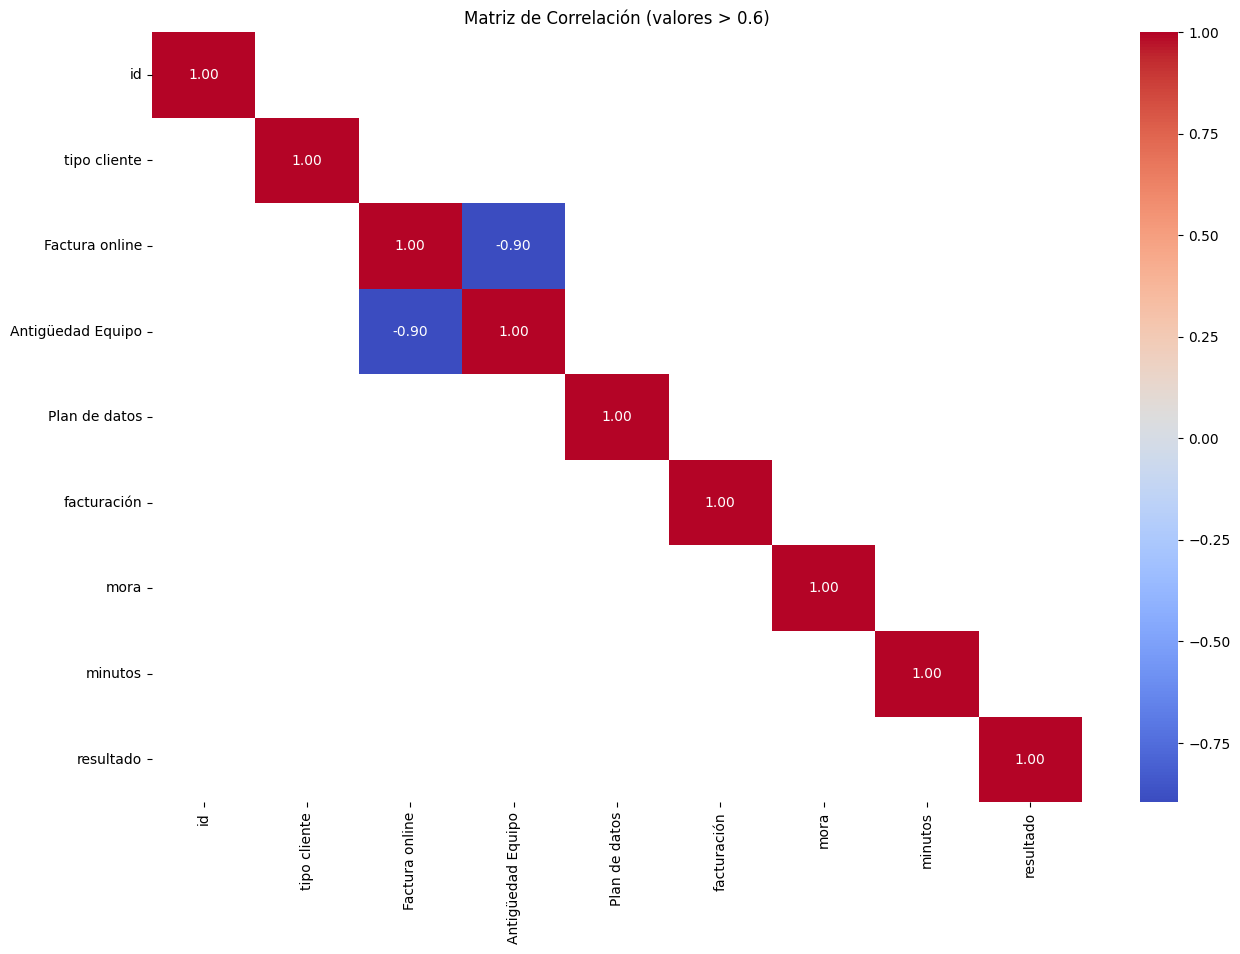

In [ ]:
#1 Correlation Matrix
numerical_data = data_train.select_dtypes(include=np.number)
data_corr = numerical_data.corr()

# Reemplaza por NaN las correlaciones < 0.6
data_corr_filtered = data_corr.where(abs(data_corr) > 0.5)

plt.figure(figsize=(15,10))
sns.heatmap(data_corr_filtered, annot=True, cmap='coolwarm', fmt=".2f")
sns.set(font_scale=1.0, style="whitegrid")
#sns.set_style("whitegrid")
plt.title("Matriz de Correlación (valores > 0.6)")
plt.show()

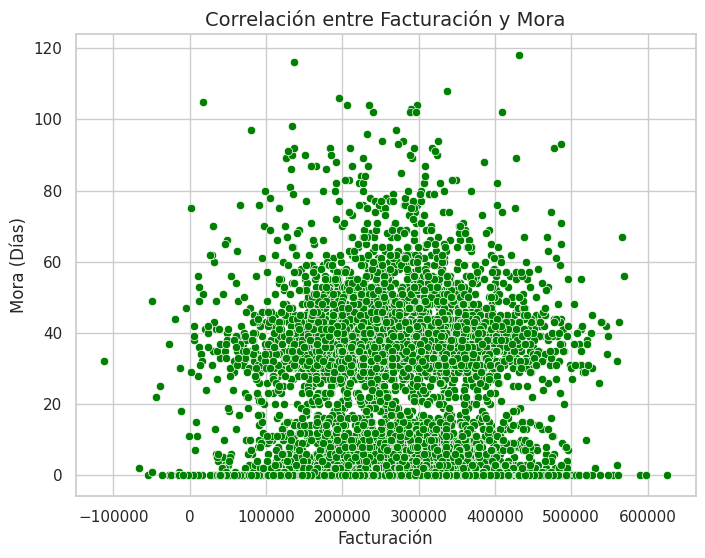

In [ ]:
# 2. Análisis bivariado: Correlación entre Facturación y Mora
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_train['facturación'], y=data_train['mora'], color='green')
plt.title('Correlación entre Facturación y Mora', fontsize=14)
plt.xlabel('Facturación', fontsize=12)
plt.ylabel('Mora (Días)', fontsize=12)
plt.grid(True)
plt.show()

Cual es el perfil general de los clientes

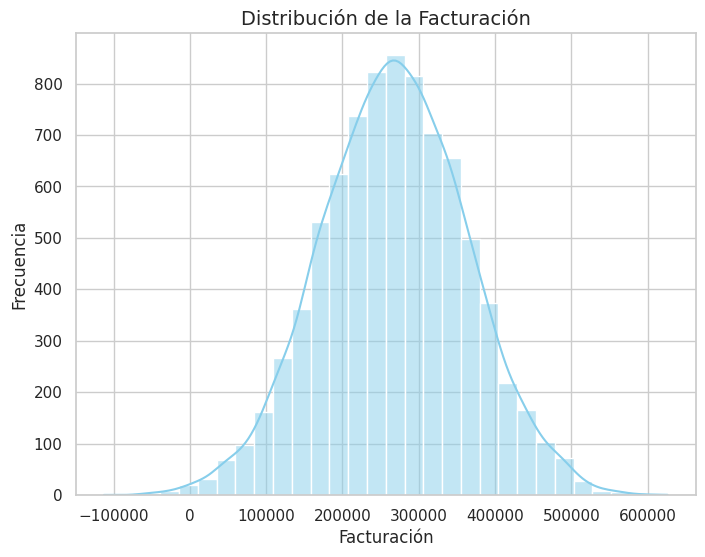

In [ ]:
# 3. Análisis univariado: Distribución de la facturación
plt.figure(figsize=(8, 6))
sns.histplot(data_train['facturación'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Facturación', fontsize=14)
plt.xlabel('Facturación', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(True)
plt.show()

<ipython-input-10-f45a4d995be4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipo cliente', data=data_train, palette='Set2')


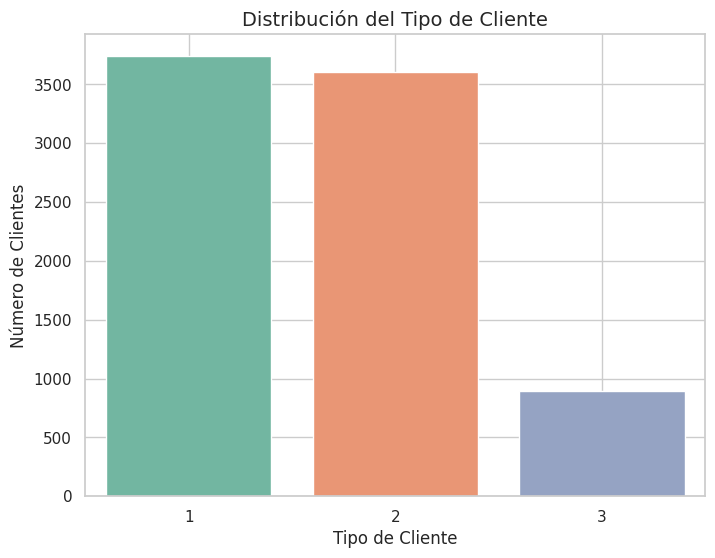

In [ ]:
# 4. Análisis univariado: Distribución del tipo de cliente
plt.figure(figsize=(8, 6))
sns.countplot(x='tipo cliente', data=data_train, palette='Set2')
plt.title('Distribución del Tipo de Cliente', fontsize=14)
plt.xlabel('Tipo de Cliente', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

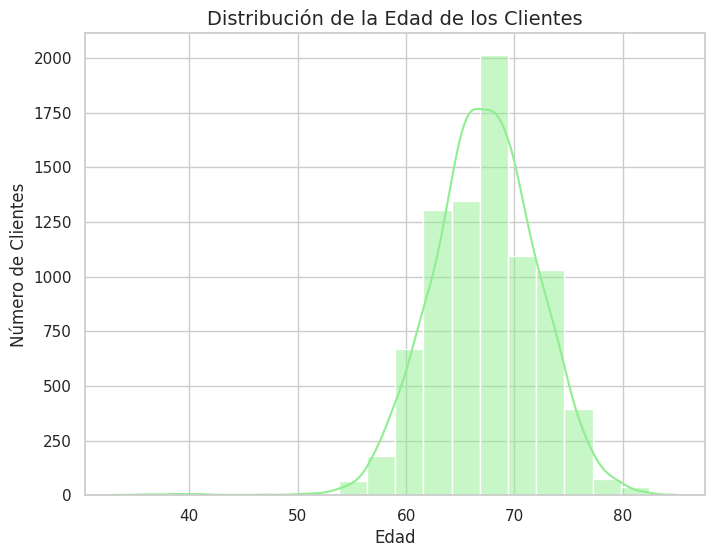

In [ ]:
#5 Calcular la edad
data_train['Edad'] = pd.to_datetime('today').year - pd.to_datetime(data_train['Fecha de nacimiento']).dt.year

# Histograma de edad
plt.figure(figsize=(8, 6))
sns.histplot(data_train['Edad'], kde=True, bins=20, color='lightgreen')
plt.title('Distribución de la Edad de los Clientes', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

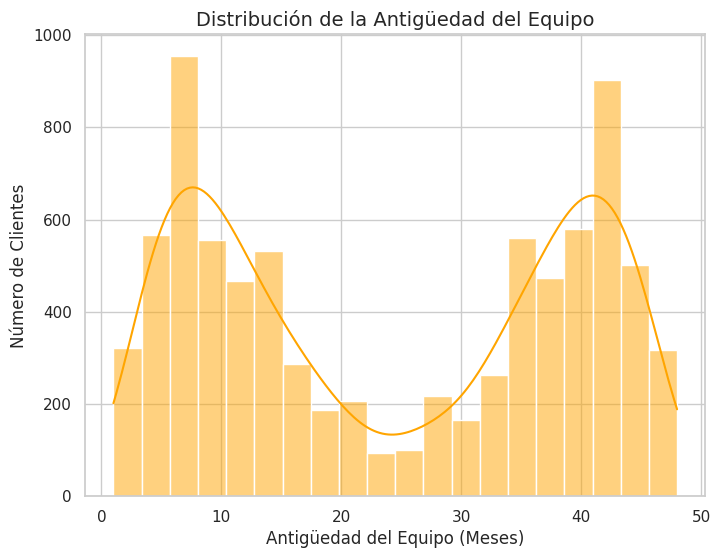

In [ ]:
# 6. Distribución de la antigüedad del equipo
plt.figure(figsize=(8, 6))
sns.histplot(data_train['Antigüedad Equipo'], kde=True, bins=20, color='orange')
plt.title('Distribución de la Antigüedad del Equipo', fontsize=14)
plt.xlabel('Antigüedad del Equipo (Meses)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

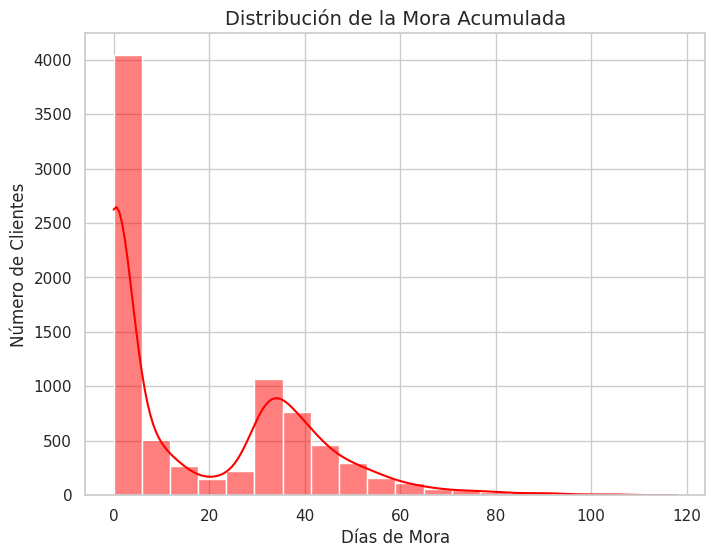

In [ ]:
# 7. Distribución de la Mora Acumulada

plt.figure(figsize=(8, 6))
sns.histplot(data_train['mora'], kde=True, bins=20, color='red')
plt.title('Distribución de la Mora Acumulada', fontsize=14)
plt.xlabel('Días de Mora', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

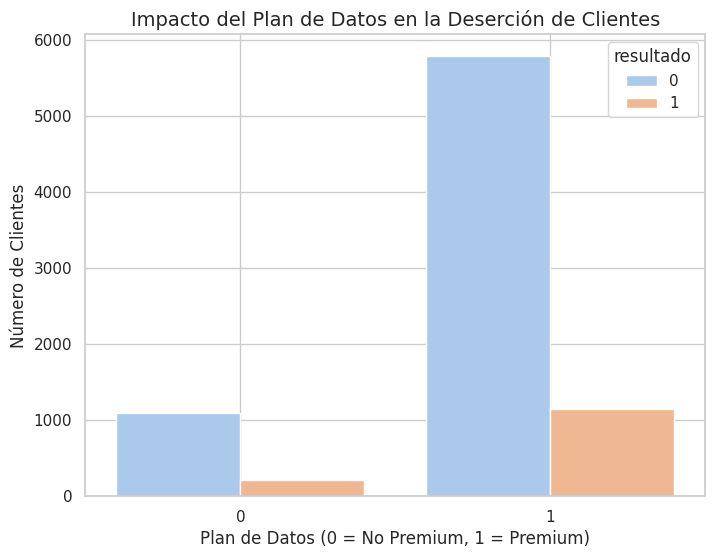

In [ ]:
# 9 Impacto del Plan de Datos en la Deserción de Clientes
plt.figure(figsize=(8, 6))
sns.countplot(x='Plan de datos', hue='resultado', data=data_train, palette='pastel')
plt.title('Impacto del Plan de Datos en la Deserción de Clientes', fontsize=14)
plt.xlabel('Plan de Datos (0 = No Premium, 1 = Premium)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

2. ¿Como se relacionan las caracteristicas de los clientes con su desercion?

<ipython-input-15-d7dff1acdf48>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='resultado', y='Antigüedad Equipo', data=data_train, palette='Set2')


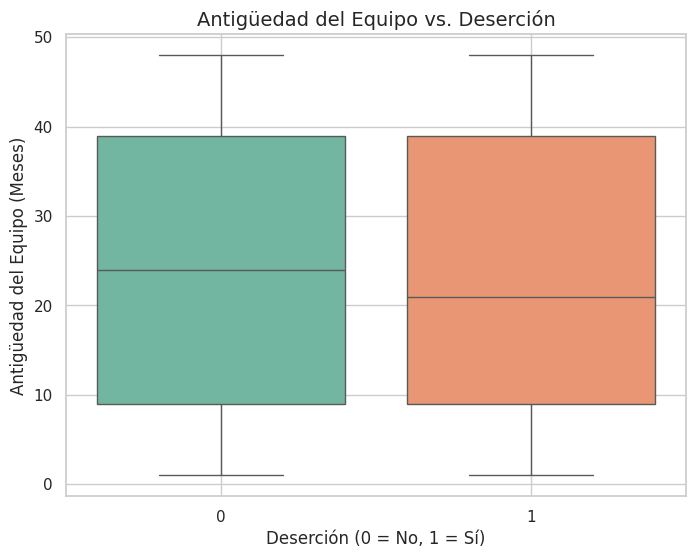

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='resultado', y='Antigüedad Equipo', data=data_train, palette='Set2')
plt.title('Antigüedad del Equipo vs. Deserción', fontsize=14)
plt.xlabel('Deserción (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Antigüedad del Equipo (Meses)', fontsize=12)
plt.grid(True)
plt.show()

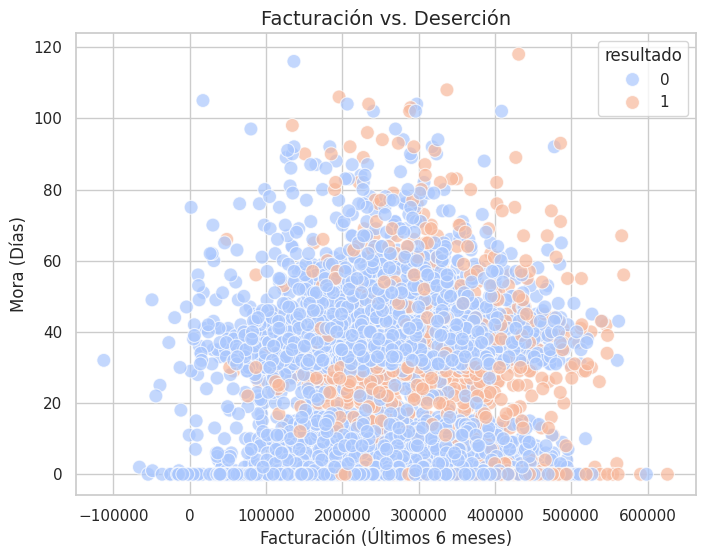

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='facturación', y='mora', hue='resultado', data=data_train, palette='coolwarm', s=100, alpha=0.7)
plt.title('Facturación vs. Deserción', fontsize=14)
plt.xlabel('Facturación (Últimos 6 meses)', fontsize=12)
plt.ylabel('Mora (Días)', fontsize=12)
plt.grid(True)
plt.show()

<ipython-input-17-a2309468d16f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='resultado', y='mora', data=data_train, palette='Set3')


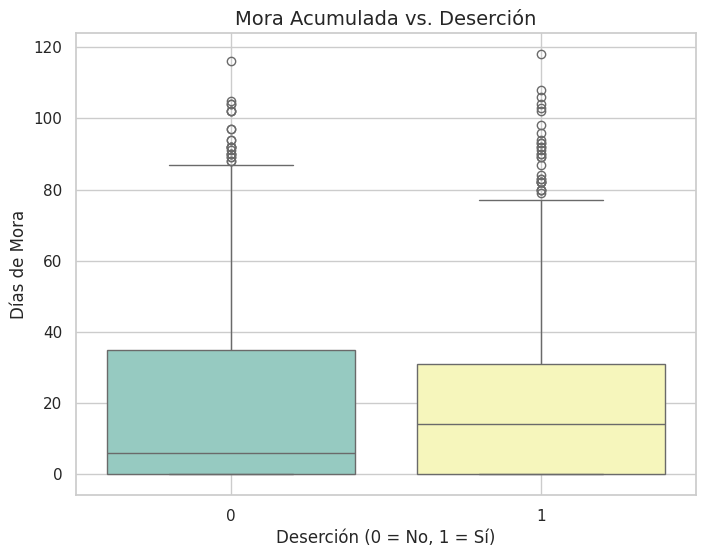

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='resultado', y='mora', data=data_train, palette='Set3')
plt.title('Mora Acumulada vs. Deserción', fontsize=14)
plt.xlabel('Deserción (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Días de Mora', fontsize=12)
plt.grid(True)
plt.show()

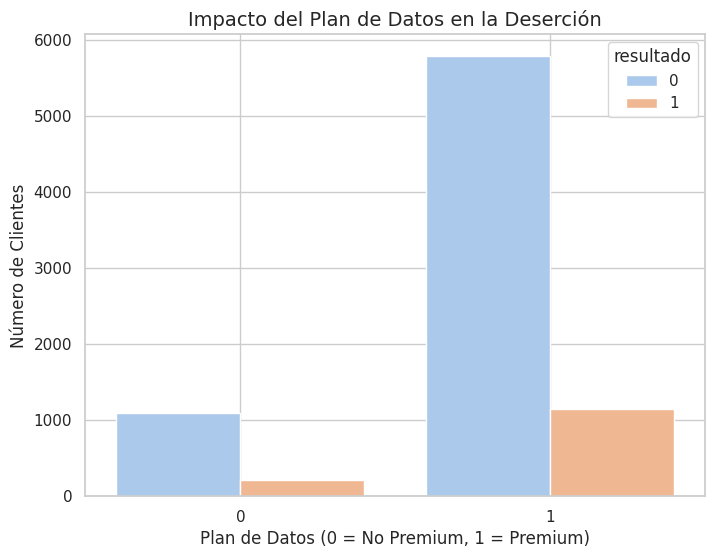

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Plan de datos', hue='resultado', data=data_train, palette='pastel')
plt.title('Impacto del Plan de Datos en la Deserción', fontsize=14)
plt.xlabel('Plan de Datos (0 = No Premium, 1 = Premium)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

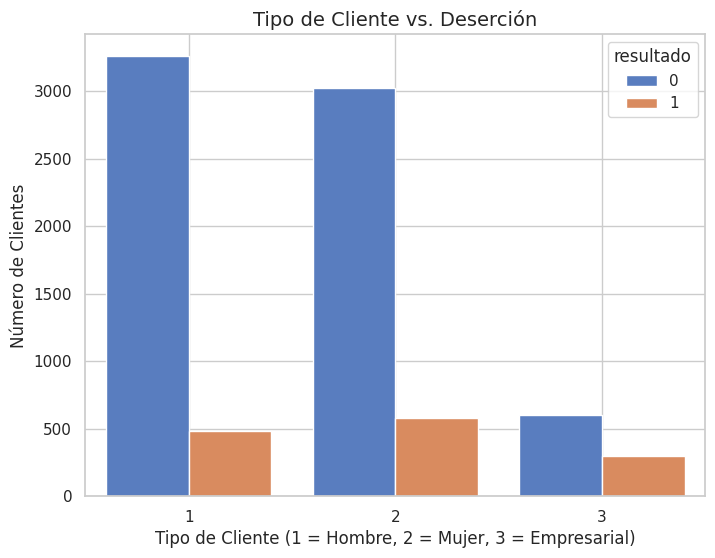

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='tipo cliente', hue='resultado', data=data_train, palette='muted')
plt.title('Tipo de Cliente vs. Deserción', fontsize=14)
plt.xlabel('Tipo de Cliente (1 = Hombre, 2 = Mujer, 3 = Empresarial)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.grid(True)
plt.show()

3.	¿Qué variables están más correlacionadas?

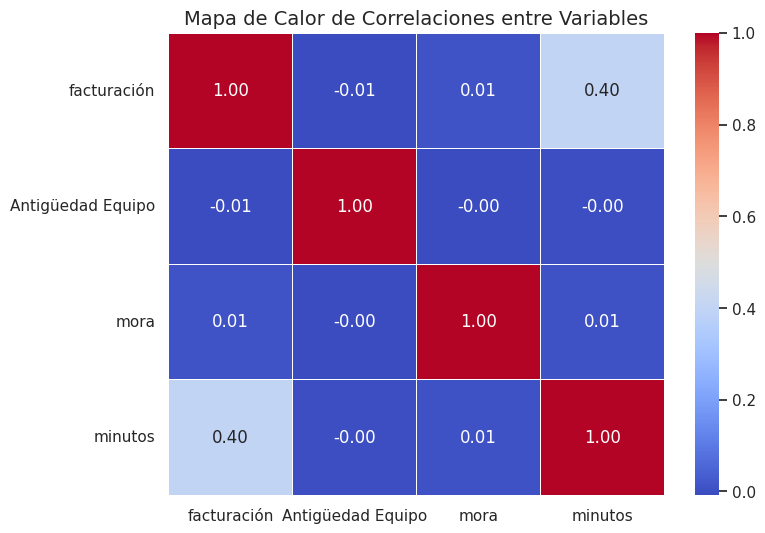

In [ ]:
corr_data = data_train[['facturación', 'Antigüedad Equipo', 'mora', 'minutos']]

# Calcular la matriz de correlación
corr_matrix = corr_data.corr()

# Heatmap de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones entre Variables', fontsize=14)
plt.show()

###Datos Atipicos

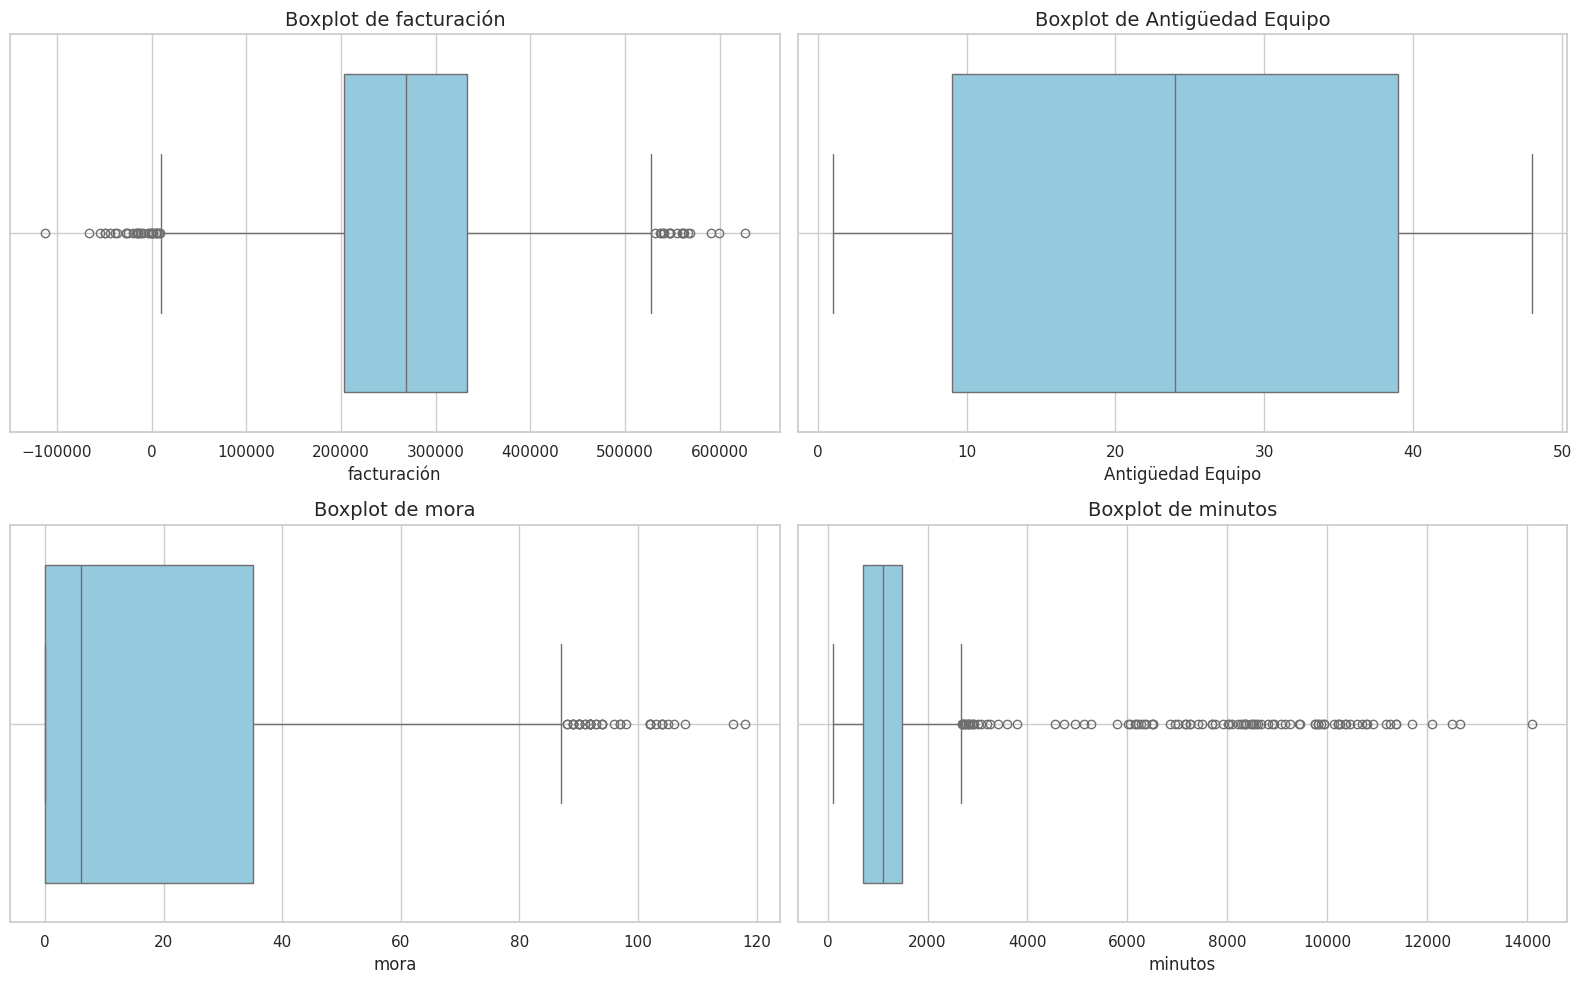

In [ ]:
# Variables numéricas a analizar
numeric_columns = ['facturación', 'Antigüedad Equipo', 'mora', 'minutos']

# Configurar estilo
sns.set(style="whitegrid")

# Crear un boxplot para cada variable numérica para identificar outliers
plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data_train[col], color='skyblue')
    plt.title(f'Boxplot de {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(True)

plt.tight_layout()
plt.show()

##Feature Engineering

Creacion de 2 nuevas variables para las fechas

In [ ]:
# Convertir columnas a datetime si no lo están
data_train['Fecha de nacimiento'] = pd.to_datetime(data_train['Fecha de nacimiento'], dayfirst=True)
data_train['Fecha inicio contrato'] = pd.to_datetime(data_train['Fecha inicio contrato'], dayfirst=True)

# Calcular Edad en años (dividiendo los días por 365)
data_train['Edad'] = (pd.Timestamp.today() - data_train['Fecha de nacimiento']).dt.days / 365

# Calcular antigüedad del contrato en meses
data_train['Antigüedad contrato (meses)'] = (pd.Timestamp.today().to_period('M') - data_train['Fecha inicio contrato'].dt.to_period('M')).apply(lambda x: x.n)

# Mostrar resultados
print(data_train[['Fecha de nacimiento', 'Edad', 'Fecha inicio contrato', 'Antigüedad contrato (meses)']].head())

      Fecha de nacimiento       Edad   Fecha inicio contrato  \
0 1990-05-01 00:05:22.046  35.063014 2017-12-22 10:09:47.504   
1 1980-06-30 19:08:57.680  44.901370 2017-07-28 02:54:52.022   
2 1984-10-10 21:23:28.869  40.619178 2017-06-29 08:15:47.525   
3 1986-07-01 08:58:42.308  38.898630 2017-03-13 18:39:25.308   
4 1986-01-23 00:26:52.782  39.334247 2015-08-02 21:50:40.258   

   Antigüedad contrato (meses)  
0                           89  
1                           94  
2                           95  
3                           98  
4                          117  


##Data Cleaning

In [ ]:
# Eliminar las columnas originales de fecha
data_train_vf = data_train.drop(columns=['Fecha de nacimiento', 'Fecha inicio contrato'])
data_train_vf.head()

,id,tipo cliente,Factura online,Antigüedad Equipo,Plan de datos,facturación,mora,minutos,resultado,Edad,Antigüedad contrato (meses)
0,5,2,1,9,0,44588,34,644,0,35.063014,89
1,8,2,0,41,1,341480,3,663,0,44.901370,94
2,9,2,0,38,1,230662,20,1039,1,40.619178,95
3,11,2,1,11,1,205336,9,535,0,38.898630,98
4,16,1,1,6,0,429525,0,1869,0,39.334247,117


In [ ]:
data_train_vf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8243 entries, 0 to 8242
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           8243 non-null   int64  
 1   tipo cliente                 8243 non-null   int64  
 2   Factura online               8243 non-null   int64  
 3   Antigüedad Equipo            8243 non-null   int64  
 4   Plan de datos                8243 non-null   int64  
 5   facturación                  8243 non-null   int64  
 6   mora                         8243 non-null   int64  
 7   minutos                      8243 non-null   int64  
 8   resultado                    8243 non-null   int64  
 9   Edad                         8243 non-null   float64
 10  Antigüedad contrato (meses)  8243 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 708.5 KB


##Data preprocessing

In [ ]:
data_train_vf1=data_train_vf.copy()

In [ ]:
data_train_vf1.drop(columns=['id'], axis=1, inplace=True)

###Get Dummies

In [ ]:
data_train_vf1=pd.get_dummies(data_train_vf1, columns=['tipo cliente'],
                              dtype='int8')
data_train_vf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8243 entries, 0 to 8242
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Factura online               8243 non-null   int64  
 1   Antigüedad Equipo            8243 non-null   int64  
 2   Plan de datos                8243 non-null   int64  
 3   facturación                  8243 non-null   int64  
 4   mora                         8243 non-null   int64  
 5   minutos                      8243 non-null   int64  
 6   resultado                    8243 non-null   int64  
 7   Edad                         8243 non-null   float64
 8   Antigüedad contrato (meses)  8243 non-null   int64  
 9   tipo cliente_1               8243 non-null   int8   
 10  tipo cliente_2               8243 non-null   int8   
 11  tipo cliente_3               8243 non-null   int8   
dtypes: float64(1), int64(8), int8(3)
memory usage: 603.9 KB


In [ ]:
x=data_train_vf1.drop(columns=['resultado'], axis=1)
y=data_train_vf1['resultado']

###Normalization

In [ ]:
y.value_counts(normalize=True)

,proportion
resultado,
0,0.83489
1,0.16511


##Balanceo

In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

###Random Oversampling

In [ ]:
ro=RandomOverSampler(random_state=123, sampling_strategy=0.62)
x_ro, y_ro=ro.fit_resample(x,y)
y_ro.value_counts()

,count
resultado,
0,6882
1,4266


In [ ]:
y_ro.value_counts(normalize=True)

,proportion
resultado,
0,0.61733
1,0.38267


###Random Undersampling

In [ ]:
ru=RandomUnderSampler(random_state=42, sampling_strategy=0.7)
x_ru, y_ru=ru.fit_resample(x,y)
y_ru.value_counts()

,count
resultado,
0,1944
1,1361


In [ ]:
y_ru.value_counts(normalize=True)

,proportion
resultado,
0,0.5882
1,0.4118


###Random SMOTETomek

In [ ]:
smote=SMOTETomek(random_state=123, sampling_strategy=0.3)
x_smote, y_smote=smote.fit_resample(x,y)
y_smote.value_counts()

,count
resultado,
0,6223
1,1405


In [ ]:
y_smote.value_counts(normalize=True)

,proportion
resultado,
0,0.81581
1,0.18419


##Modeling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_ro, y_ro, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

###Logistic Regression

In [ ]:
LogR_model = LogisticRegression(penalty= 'elasticnet', l1_ratio= 0.8, solver='saga')
LogR_model.fit(X_train_sc, y_train)
y_pred_logR = LogR_model.predict(X_test_sc)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'saga']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train_sc, y_train)
best_params = grid.best_params_
print("Mejores parámetros encontrados:", best_params)

Mejores parámetros encontrados: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}


In [ ]:
LogR_model = LogisticRegression(penalty= 'l2', solver='saga', C=0.015)
LogR_model.fit(X_train_sc, y_train)
y_pred_logR = LogR_model.predict(X_test_sc)

####Metrics

In [ ]:
print(f'Accuracy Score: {accuracy_score(y_test, y_pred_logR)}')
print(f'ROC AUC: {roc_auc_score(y_test, y_pred_logR)}')
print(f'Precision Score: {precision_score(y_test, y_pred_logR)}')
print(f'Recall Score: {recall_score(y_test, y_pred_logR)}')
print(f'F1 Score: {f1_score(y_test, y_pred_logR)}')

Accuracy Score: 0.7402092675635277
ROC AUC: 0.6985422434367541
Precision Score: 0.6998950682056663
Recall Score: 0.5336
F1 Score: 0.6055379028597367


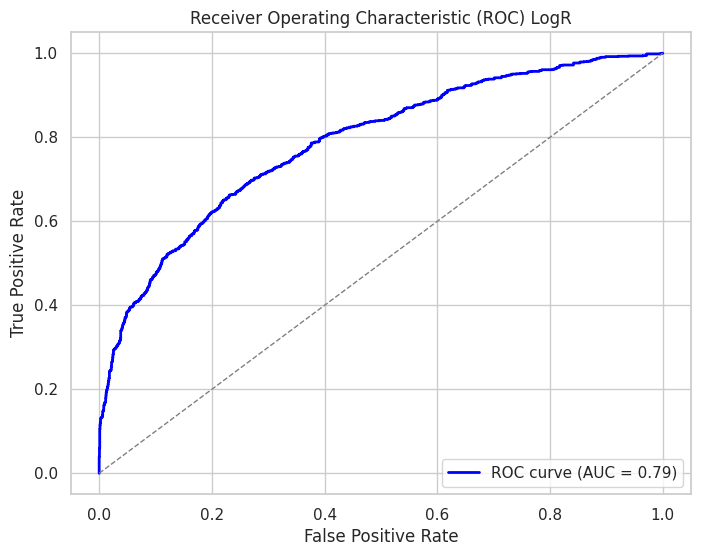

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = LogR_model.predict_proba(X_test_sc)[:, 1]
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) LogR')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
print(confusion_matrix(y_test, y_pred_logR))

[[1791  304]
 [ 576  674]]


###SVM

In [ ]:
SVM_model = svm.SVC(probability = True)
SVM_model.fit(X_train_sc, y_train)
y_pred_svm = SVM_model.predict(X_test_sc)

####Metrics

In [ ]:
print(f'Accuracy Score: {accuracy_score(y_test, y_pred_svm)}')
print(f'ROC AUC: {roc_auc_score(y_test, y_pred_svm)}')
print(f'Precision Score: {precision_score(y_test, y_pred_svm)}')
print(f'Recall Score: {recall_score(y_test, y_pred_svm)}')
print(f'F1 Score: {f1_score(y_test, y_pred_svm)}')

Accuracy Score: 0.7548579970104634
ROC AUC: 0.7083007159904534
Precision Score: 0.7443181818181818
Recall Score: 0.524
F1 Score: 0.6150234741784038


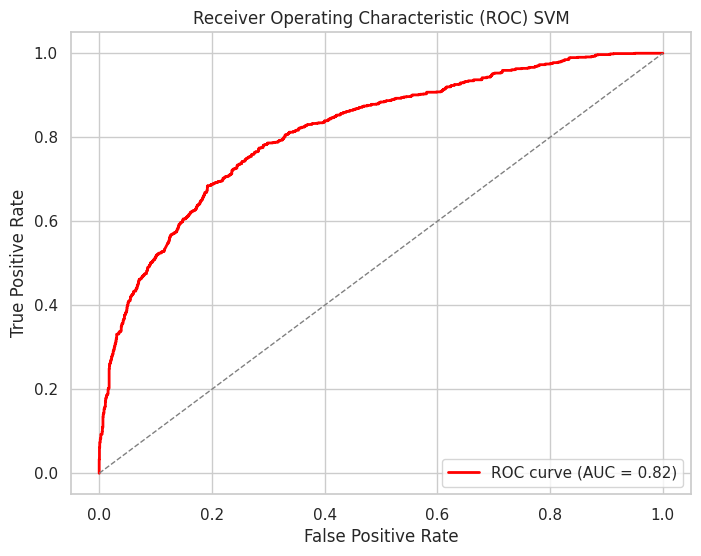

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_svm = SVM_model.predict_proba(X_test_sc)[:, 1]
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

# Calcular el AUC
roc_auc = roc_auc_score(y_test, y_prob_svm)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


##Test

In [ ]:
data_test=pd.read_excel('/content/testelco.xlsx')
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     2000 non-null   int64         
 1   Fecha de nacimiento    2000 non-null   datetime64[ns]
 2   tipo cliente           2000 non-null   int64         
 3   Factura online         2000 non-null   int64         
 4   Antigüedad Equipo      2000 non-null   int64         
 5   Plan de datos          2000 non-null   int64         
 6   facturación            2000 non-null   int64         
 7   mora                   2000 non-null   int64         
 8   Fecha inicio contrato  2000 non-null   datetime64[ns]
 9   minutos                2000 non-null   int64         
dtypes: datetime64[ns](2), int64(8)
memory usage: 156.4 KB


In [ ]:
id_test=data_test['id']

In [ ]:
# Convertir columnas a datetime si no lo están
data_test['Fecha de nacimiento'] = pd.to_datetime(data_test['Fecha de nacimiento'], dayfirst=True)
data_test['Fecha inicio contrato'] = pd.to_datetime(data_test['Fecha inicio contrato'], dayfirst=True)

# Calcular Edad en años (dividiendo los días por 365)
data_test['Edad'] = (pd.Timestamp.today() - data_test['Fecha de nacimiento']).dt.days / 365

# Calcular antigüedad del contrato en meses
data_test['Antigüedad contrato (meses)'] = (pd.Timestamp.today().to_period('M') - data_test['Fecha inicio contrato'].dt.to_period('M')).apply(lambda x: x.n)

# Mostrar resultados
print(data_test[['Fecha de nacimiento', 'Edad', 'Fecha inicio contrato', 'Antigüedad contrato (meses)']].head())

      Fecha de nacimiento       Edad   Fecha inicio contrato  \
0 1996-10-28 20:37:48.858  28.561644 2016-08-01 18:35:57.816   
1 1985-11-08 12:29:16.237  39.542466 2016-04-01 19:20:55.326   
2 1987-08-15 05:31:09.530  37.775342 2017-10-12 05:47:50.487   
3 1981-11-06 04:06:28.190  43.550685 2018-02-09 20:47:49.340   
4 1986-08-03 13:43:36.300  38.808219 2017-02-01 17:42:17.169   

   Antigüedad contrato (meses)  
0                          105  
1                          109  
2                           91  
3                           87  
4                           99  


In [ ]:
# Eliminar las columnas originales de fecha
data_test_vf = data_test.drop(columns=['Fecha de nacimiento', 'Fecha inicio contrato'])
data_test_vf.head()

,id,tipo cliente,Factura online,Antigüedad Equipo,Plan de datos,facturación,mora,minutos,Edad,Antigüedad contrato (meses)
0,13,2,0,18,1,319690,0,1202,28.561644,105
1,14,2,1,6,1,333812,0,1403,39.542466,109
2,20,2,0,35,1,224201,43,659,37.775342,91
3,30,1,1,11,1,210614,33,912,43.550685,87
4,37,1,0,34,1,267116,15,1622,38.808219,99


In [ ]:
data_test_vf=pd.get_dummies(data_test_vf, columns=['tipo cliente'],
                              dtype='int8')
data_test_vf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           2000 non-null   int64  
 1   Factura online               2000 non-null   int64  
 2   Antigüedad Equipo            2000 non-null   int64  
 3   Plan de datos                2000 non-null   int64  
 4   facturación                  2000 non-null   int64  
 5   mora                         2000 non-null   int64  
 6   minutos                      2000 non-null   int64  
 7   Edad                         2000 non-null   float64
 8   Antigüedad contrato (meses)  2000 non-null   int64  
 9   tipo cliente_1               2000 non-null   int8   
 10  tipo cliente_2               2000 non-null   int8   
 11  tipo cliente_3               2000 non-null   int8   
dtypes: float64(1), int64(8), int8(3)
memory usage: 146.6 KB


In [ ]:
x_test=data_test_vf.drop(columns=['id'], axis=1)

In [ ]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
x_test_sc=sc.transform(x_test)

In [ ]:
y_pred_test=SVM_model.predict(x_test_sc)

In [ ]:
y_pred_test_LogR=LogR_model.predict(x_test_sc)

In [ ]:
resultado=pd.DataFrame({
    'id': id_test,
    'resultado': y_pred_test})
resultado.to_csv('predicciones_churn_SVM.csv', index=False, sep=',')
print('Listo SVM')

Listo SVM


In [ ]:
resultado=pd.DataFrame({
    'id': id_test,
    'resultado': y_pred_test_LogR})
resultado.to_csv('predicciones_churn_LogR.csv', index=False, sep=',')
print('Listo LogR')

Listo LogR
